# Рубежный контроль №1 по Машинному обучению.
## Шитова Милана 
## Группа ИБМ3-65Б
Вариант 23. Датасет № 7.
Задание. Для заданного набора данных произведите масштабирование данных (для одного признака) и преобразование категориальных признаков в количественные двумя способами (label encoding, one hot encoding) для одного признака. Какие методы Вы использовали для решения задачи и почему?

### 1. Загрузка данных с kaggle

In [108]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lava18/google-play-store-apps")

print("Path to dataset files:", path)

Path to dataset files: /Users/anlimka/.cache/kagglehub/datasets/lava18/google-play-store-apps/versions/6


### 2. Загрузка библиотек и первоначальных вид данных

In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [293]:
data = pd.read_csv("/Users/anlimka/Desktop/МЛ/googleplaystore.csv", )
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [247]:
data.shape

(10841, 13)

In [248]:
data.dtypes

App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

По результатам кода видно, что почти всех колонки типа str, но в реальности признаки Reviews, Price, Installs можно представить числовыми, а Last Updated датой, преобразуем некоторые из них, остальные преобразуем в object (это не обязательно, мне просто захотелось).

In [294]:
# Преобразование в reviews встречается M вместо числового обозначения миллионов, поэтому нужна функция преобразования
def convert(value):
    if isinstance(value, str):
        value = value.upper().strip()
        if 'M' in value:
            return float(value.replace('M', '')) * 1000000
        else:
            return float(value)
    return float(value)

data['Last Updated'] = pd.to_datetime(data['Last Updated'], format='%B %d, %Y', errors='coerce')
data['Reviews'] = data['Reviews'].apply(convert).astype(float)
string_cols = data.select_dtypes(include=['string']).columns
data[string_cols] = data[string_cols].astype('object')

In [250]:
data.dtypes

App                       object
Category                  object
Rating                   float64
Reviews                  float64
Size                      object
Installs                  object
Type                      object
Price                     object
Content Rating            object
Genres                    object
Last Updated      datetime64[us]
Current Ver               object
Android Ver               object
dtype: object

### 3. Проверяем на наличие пропусков

In [251]:
data.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         1
Current Ver          8
Android Ver          3
dtype: int64

В итоге видим пропуски в колонках Rating, Type, Content Rating, Current Ver, Android Ver, Last Updated, причем все признаки имеют тип данных Object, кроме Rating и Last Updated. Я решила заполнить пропущенные значения Rating средним значением по столбцу, пропущенные категориальные признаки - наиболее часто встречающимеся, а строку с пропущенной датой удалить.

### 4. Обработка пропусков в количественных данных

In [295]:
total_count = data.shape[0]
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Rating. Тип данных float64. Количество пустых значений 1474, 13.6%.


In [296]:
mean_Rating = data['Rating'].mean()
data['Rating'] = data['Rating'].fillna(mean_Rating)

### 5. Обработка пропусков в категориальных данных

In [297]:
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Type. Тип данных object. Количество пустых значений 1, 0.01%.
Колонка Content Rating. Тип данных object. Количество пустых значений 1, 0.01%.
Колонка Current Ver. Тип данных object. Количество пустых значений 8, 0.07%.
Колонка Android Ver. Тип данных object. Количество пустых значений 3, 0.03%.


 Вообще пропусков незначительное количество, поэтому можно было бы удалить строки с пропущенными категориальными значениями, но я решила заполнить их наиболее частыми значениями

In [298]:
from sklearn.impute import SimpleImputer

In [299]:
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_cols = data.select_dtypes(include=['object', 'category']).columns
data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,"10,000+",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,"50,000,000+",Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [300]:
data = data.dropna(axis=0, how='any') # Тут удаляю оставшийся пропуск от Last Updated

In [301]:
# Проверка на пропуски
data.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [302]:
data.shape # было 10841

(10840, 13)

### 6. Построение гистограммы

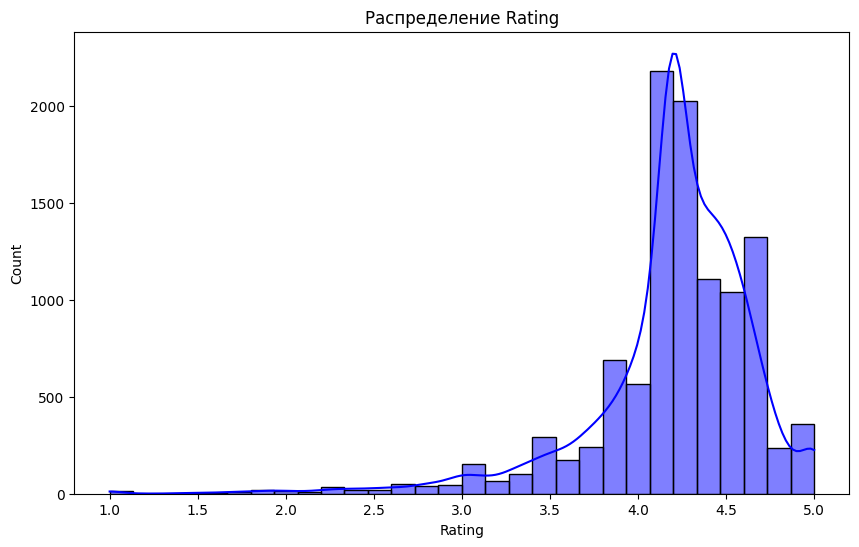

In [303]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Rating', bins=30, kde=True, color='blue')
plt.title('Распределение Rating')
plt.show()

### 7. Масштабирование признака Rating

In [304]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [305]:
sc1 = MinMaxScaler()
data['MinMax_Rating'] = sc1.fit_transform(data[['Rating']])

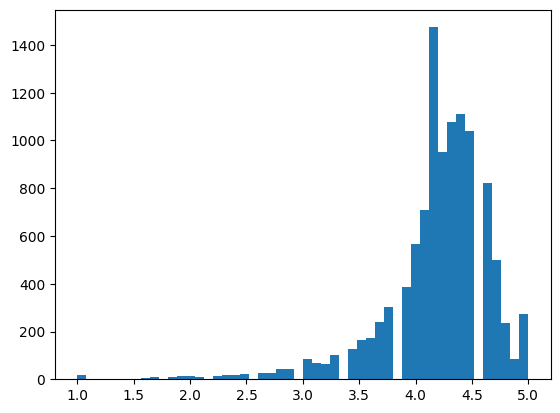

In [306]:
plt.hist(data['Rating'], 50)
plt.show()

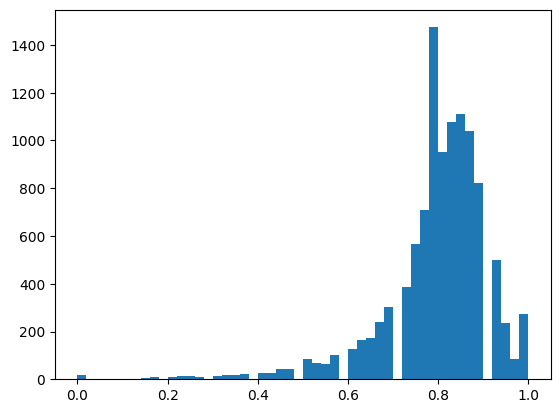

In [307]:
plt.hist(data['MinMax_Rating'], 50)
plt.show()

In [308]:
sc2 = StandardScaler()
data['StandardScaler_Rating'] = sc2.fit_transform(data[['Rating']])

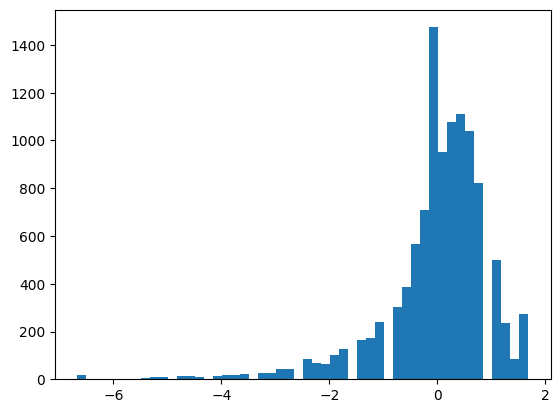

In [309]:
plt.hist(data['StandardScaler_Rating'], 50)
plt.show()

### 8. Кодирование категорий целочисленными значениями 
### Начнем с LabelEncoder

In [310]:
from sklearn.preprocessing import LabelEncoder

In [311]:
le = LabelEncoder()
data['New_cat_L'] = le.fit_transform(data['Content Rating'])

In [312]:
print(f"Наименования категорий в соответствии с порядковыми номерами: {le.classes_}")
print(f"Категориальный признак и его числовое преставление:\n {data[['Content Rating', 'New_cat_L']]}")
print(f"Уникальные значения массива: {np.unique(data['New_cat_L'])}")

Наименования категорий в соответствии с порядковыми номерами: ['Adults only 18+' 'Everyone' 'Everyone 10+' 'Mature 17+' 'Teen' 'Unrated']
Категориальный признак и его числовое преставление:
       Content Rating  New_cat_L
0           Everyone          1
1           Everyone          1
2           Everyone          1
3               Teen          4
4           Everyone          1
...              ...        ...
10836       Everyone          1
10837       Everyone          1
10838       Everyone          1
10839     Mature 17+          3
10840       Everyone          1

[10840 rows x 2 columns]
Уникальные значения массива: [0 1 2 3 4 5]


Как результат в таблицу добавилась колонка с предствлением категориального признака количествнным, этот класс преимущественно предназначен для кодирования целевых признаков, перед кодированием уникальные значения признака сортируются в лексикографиеском порядке.

### Теперь применим метод one-hot encoding.
В этом случае каждое уникальное значение признака становится новым отдельным признаком.

In [313]:
one_hot = pd.get_dummies(data['Content Rating'])
data = pd.concat([data, one_hot], axis=1)
one_hot.head()

,Adults only 18+,Everyone,Everyone 10+,Mature 17+,Teen,Unrated
0,False,True,False,False,False,False
1,False,True,False,False,False,False
2,False,True,False,False,False,False
3,False,False,False,False,True,False
4,False,True,False,False,False,False


In [314]:
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Android Ver,MinMax_Rating,StandardScaler_Rating,New_cat_L,Adults only 18+,Everyone,Everyone 10+,Mature 17+,Teen,Unrated
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,"10,000+",Free,0,Everyone,Art & Design,...,4.0.3 and up,0.775,-0.192055,1,False,True,False,False,False,False
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,...,4.0.3 and up,0.725,-0.609692,1,False,True,False,False,False,False
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,...,4.0.3 and up,0.925,1.060855,1,False,True,False,False,False,False
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,"50,000,000+",Free,0,Teen,Art & Design,...,4.2 and up,0.875,0.643218,4,False,False,False,False,True,False
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,...,4.4 and up,0.825,0.225582,1,False,True,False,False,False,False


Как видим в таблицу добавились масштабированные двумя способами занчения параметра Rating и преобразованный двумя способами признак Content Rating.

## Выводы
### Для решения задачи масштабирования я воспользовалась двумя методами MinMax масштабированием и Масштабирование данных на основе Z-оценки. Так как у меня ет конкретной задачи восстановления регресии или работы с выбросами, не нужен конкретный диапазон, я применила оба метода. в будущем при поставленной задаче можно попробовать оба метода и сравнить какой будет лучше. Для преобразования качественных признаков я использовала методы из задания. Для преобразования label encoding я использовала иблиотеку sklearn, а для one hot encoding Pandas get_dummies, потому что он быстрее и проще.